# Business Problem

Amazon wants to analyze its sales data to understand customer purchasing patterns, product performance, and operational efficiency.

The company has collected transactional sales data from different regions, product categories, and fulfillment methods. However, raw data alone does not provide actionable insights for business decision-making.

The objective of this project is to clean, analyze, and visualize the sales data to answer important business questions that can help improve sales performance, inventory planning, customer satisfaction, and overall business strategy.

# Business Objectives

This project aims to answer the following business questions:

- Which product categories generate the highest sales?
- Which states contribute the most revenue?
- How do monthly sales change over time?
- Which products are sold the most?
- What are the most common order statuses?
- Which fulfillment method performs better?
- Which customer segments contribute the most sales?
- What business insights can help increase revenue and improve operational efficiency?

# Project Workflow

1. Data Loading
2. Data Understanding
3. Data Cleaning
4. Data Quality Assessment
5. Feature Engineering
6. Exploratory Data Analysis (EDA)
7. Business Insights
8. Recommendations
9. Conclusion

* Data Loading


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sqlalchemy import create_engine
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv(r"C:\Users\dell\Documents\Data Analysis files\Amazon_sales\data\Amazon Sale Report.csv")

In [3]:
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,94760,171-0243036-7059512,6/26/2022,Shipped,Amazon,Amazon.in,Expedited,SET389,SET389-KR-NP-S,Set,...,INR,648.00,VASAI VIRAR,MAHARASHTRA,401209.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,False
1,1,171-9198151-1101146,4/30/2022,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,4/30/2022,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,4/30/2022,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,4/30/2022,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


* Checking for null values

In [4]:
df.drop(columns=["index"], inplace=True)
df.reset_index(drop=True, inplace=True)

In [5]:
df.isnull().sum()

Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category                  0
Size                      0
ASIN                      0
Courier Status         6872
Qty                       0
currency               7795
Amount                 7795
ship-city                33
ship-state               33
ship-postal-code         33
ship-country             33
promotion-ids         49153
B2B                       0
fulfilled-by          89698
Unnamed: 22           49050
dtype: int64

In [6]:
df.shape

(128975, 23)

In [7]:
df.columns

Index(['Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by', 'Unnamed: 22'],
      dtype='object')

* drop column "fulfilled-by": missing values:> 89698
* drop column "promotion-ids": missing values:> 49153
* drop column "Unnamed: 22": missing values:> 49050


In [8]:
df=df.drop("Unnamed: 22",axis=1)
df=df.drop("promotion-ids",axis=1)
df=df.drop("fulfilled-by",axis=1)

In [9]:
df.describe()

,Qty,Amount,ship-postal-code
count,128975.000000,121180.000000,128942.000000
mean,0.904431,648.561465,463966.236509
std,0.313354,281.211687,191476.764941
min,0.000000,0.000000,110001.000000
25%,1.000000,449.000000,382421.000000
50%,1.000000,605.000000,500033.000000
75%,1.000000,788.000000,600024.000000
max,15.000000,5584.000000,989898.000000


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 20 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Order ID            128975 non-null  object 
 1   Date                128975 non-null  object 
 2   Status              128975 non-null  object 
 3   Fulfilment          128975 non-null  object 
 4   Sales Channel       128975 non-null  object 
 5   ship-service-level  128975 non-null  object 
 6   Style               128975 non-null  object 
 7   SKU                 128975 non-null  object 
 8   Category            128975 non-null  object 
 9   Size                128975 non-null  object 
 10  ASIN                128975 non-null  object 
 11  Courier Status      122103 non-null  object 
 12  Qty                 128975 non-null  int64  
 13  currency            121180 non-null  object 
 14  Amount              121180 non-null  float64
 15  ship-city           128942 non-nul

In [11]:
df["currency"].value_counts()

currency
INR    121180
Name: count, dtype: int64

In [12]:
df=df.drop("currency",axis=1)

In [13]:
df["Courier Status"].value_counts()

Courier Status
Shipped      109487
Unshipped      6681
Cancelled      5935
Name: count, dtype: int64

* amount fill with median
* courier status fill with mode
* ship postal code fill with median
* [ship_city,ship_country,ship_state] fill with mode

In [14]:
 df["Amount"].fillna(df["Amount"].median(),inplace=True)

In [15]:
mode1=df['Courier Status'].mode()[0]

In [16]:
df["Courier Status"]=df["Courier Status"].fillna(mode1)

In [17]:
df["ship-postal-code"].fillna(df["ship-postal-code"].median(),inplace=True)

In [18]:
ship=df["ship-city"].mode()[0]
ship_c=df["ship-country"].mode()[0]
ship_s=df["ship-state"].mode()[0]

In [19]:
df["ship-city"]=df["ship-city"].fillna(ship)
df["ship-country"]=df["ship-country"].fillna(ship_c)
df["ship-state"]=df["ship-state"].fillna(ship_s)


In [20]:
df.isnull().sum()

Order ID              0
Date                  0
Status                0
Fulfilment            0
Sales Channel         0
ship-service-level    0
Style                 0
SKU                   0
Category              0
Size                  0
ASIN                  0
Courier Status        0
Qty                   0
Amount                0
ship-city             0
ship-state            0
ship-postal-code      0
ship-country          0
B2B                   0
dtype: int64

In [21]:
df.head()

,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B
0,171-0243036-7059512,6/26/2022,Shipped,Amazon,Amazon.in,Expedited,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,Shipped,1,648.00,VASAI VIRAR,MAHARASHTRA,401209.0,IN,False
1,171-9198151-1101146,4/30/2022,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,406.00,BENGALURU,KARNATAKA,560085.0,IN,False
2,404-0687676-7273146,4/30/2022,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,True
3,403-9615377-8133951,4/30/2022,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,Shipped,0,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,False
4,407-1069790-7240320,4/30/2022,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,574.00,CHENNAI,TAMIL NADU,600073.0,IN,False


* Inconsistent formats:
* 
 -Standardized category names
 -replace rajshthan to rajasthan , rj to rajasthan

In [22]:
df["ship-state"].value_counts()

ship-state
MAHARASHTRA      22293
KARNATAKA        17326
TAMIL NADU       11483
TELANGANA        11330
UTTAR PRADESH    10638
                 ...  
Nagaland             1
Mizoram              1
bihar                1
rajsthan             1
Rajsthan             1
Name: count, Length: 69, dtype: int64

In [23]:
df["ship-state"]=df["ship-state"].str.lower()

In [24]:
df['ship-state']=df["ship-state"].replace("rajshthan","rajasthan")


In [25]:
df['ship-state']=df["ship-state"].replace("rajsthan","rajasthan")


In [26]:
df['ship-state']=df["ship-state"].replace("rj","rajasthan")


In [27]:
df['ship-state']=df["ship-state"].replace("punjab/mohali/zirakpur","punjab")


In [28]:
df['ship-state']=df["ship-state"].replace("pb","punjab")


In [29]:
df['ship-state']=df["ship-state"].replace("nl","nagaland")


In [30]:
df['ship-state']=df["ship-state"].replace("ar","arunachal pradesh")


In [31]:
df['ship-state']=df["ship-state"].replace("apo","Unknown")


In [32]:
df['ship-state']=df["ship-state"].replace("in","Unknown")
df['ship-state']=df["ship-state"].replace("orissa","odisha")
df['ship-state']=df["ship-state"].replace("puducherry","pondicherry")

In [33]:
df["ship-state"]=df["ship-state"].str.replace(" ","_")

In [34]:
df["ship-state"].value_counts()

ship-state
maharashtra           22293
karnataka             17326
tamil_nadu            11483
telangana             11330
uttar_pradesh         10638
delhi                  6967
kerala                 6585
west_bengal            5963
andhra_pradesh         5430
gujarat                4489
haryana                4415
rajasthan              2718
madhya_pradesh         2529
odisha                 2139
bihar                  2114
punjab                 1919
assam                  1663
uttarakhand            1553
jharkhand              1456
goa                    1137
chhattisgarh            909
himachal_pradesh        788
jammu_&_kashmir         702
pondicherry             351
chandigarh              333
manipur                 316
andaman_&_nicobar_      257
meghalaya               207
sikkim                  205
nagaland                187
tripura                 151
arunachal_pradesh       147
new_delhi                81
mizoram                  76
dadra_and_nagar          70
ladakh   

In [35]:
df.columns


Index(['Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'Amount', 'ship-city', 'ship-state',
       'ship-postal-code', 'ship-country', 'B2B'],
      dtype='object')

In [36]:
df.columns=df.columns.str.lower().str.replace(" ","_")

In [37]:
df.head()

,order_id,date,status,fulfilment,sales_channel_,ship-service-level,style,sku,category,size,asin,courier_status,qty,amount,ship-city,ship-state,ship-postal-code,ship-country,b2b
0,171-0243036-7059512,6/26/2022,Shipped,Amazon,Amazon.in,Expedited,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,Shipped,1,648.00,VASAI VIRAR,maharashtra,401209.0,IN,False
1,171-9198151-1101146,4/30/2022,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,406.00,BENGALURU,karnataka,560085.0,IN,False
2,404-0687676-7273146,4/30/2022,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,329.00,NAVI MUMBAI,maharashtra,410210.0,IN,True
3,403-9615377-8133951,4/30/2022,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,Shipped,0,753.33,PUDUCHERRY,pondicherry,605008.0,IN,False
4,407-1069790-7240320,4/30/2022,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,574.00,CHENNAI,tamil_nadu,600073.0,IN,False


# Data Quality Assessment

Before performing exploratory data analysis, it is essential to evaluate the quality of the dataset. Poor-quality data can lead to incorrect conclusions and unreliable business decisions.

In this section, we assess the dataset for potential data quality issues such as duplicate records, incorrect data types, invalid values, inconsistent categories, and logical inconsistencies. This ensures that the dataset is accurate, reliable, and ready for analysis.

 Dataset Shape

In [38]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 128975
Columns: 19


 Verified the dimensions of the dataset.

* Data Types

In [39]:
df.dtypes

order_id               object
date                   object
status                 object
fulfilment             object
sales_channel_         object
ship-service-level     object
style                  object
sku                    object
category               object
size                   object
asin                   object
courier_status         object
qty                     int64
amount                float64
ship-city              object
ship-state             object
ship-postal-code      float64
ship-country           object
b2b                      bool
dtype: object

Inspected data types for all columns.

* Duplicate Records

In [40]:
df.duplicated().sum()

np.int64(6)

Checked for duplicate records

* Duplicate Order IDs

In [41]:
df["order_id"].duplicated().sum()

np.int64(8597)

checked for duplicate order ids or geniune or not

In [42]:
df.isna().sum()

order_id              0
date                  0
status                0
fulfilment            0
sales_channel_        0
ship-service-level    0
style                 0
sku                   0
category              0
size                  0
asin                  0
courier_status        0
qty                   0
amount                0
ship-city             0
ship-state            0
ship-postal-code      0
ship-country          0
b2b                   0
dtype: int64

In [43]:
df.describe()

,qty,amount,ship-postal-code
count,128975.000000,128975.000000,128975.000000
mean,0.904431,645.928694,463975.464679
std,0.313354,272.778829,191453.136230
min,0.000000,0.000000,110001.000000
25%,1.000000,459.000000,382421.000000
50%,1.000000,605.000000,500033.000000
75%,1.000000,771.000000,600024.000000
max,15.000000,5584.000000,989898.000000


In [44]:
df["date"].min()

'3/31/2022'

In [45]:
df["date"].max()

'6/9/2022'

In [46]:
df["status"].value_counts()

status
Shipped                          77804
Shipped - Delivered to Buyer     28769
Cancelled                        18332
Shipped - Returned to Seller      1953
Shipped - Picked Up                973
Pending                            658
Pending - Waiting for Pick Up      281
Shipped - Returning to Seller      145
Shipped - Out for Delivery          35
Shipped - Rejected by Buyer         11
Shipping                             8
Shipped - Lost in Transit            5
Shipped - Damaged                    1
Name: count, dtype: int64

In [47]:
df["category"].value_counts()

category
Set              50284
kurta            49877
Western Dress    15500
Top              10622
Ethnic Dress      1159
Blouse             926
Bottom             440
Saree              164
Dupatta              3
Name: count, dtype: int64

In [48]:
df['fulfilment'].value_counts()

fulfilment
Amazon      89698
Merchant    39277
Name: count, dtype: int64

In [49]:
df['size'].value_counts()

size
M       22711
L       22132
XL      20876
XXL     18096
S       17090
3XL     14816
XS      11161
6XL       738
5XL       550
4XL       427
Free      378
Name: count, dtype: int64

In [50]:
df['courier_status'].value_counts()

courier_status
Shipped      116359
Unshipped      6681
Cancelled      5935
Name: count, dtype: int64

In [51]:
df["ship-city"].value_counts()

ship-city
BENGALURU              11250
HYDERABAD               8074
MUMBAI                  6126
NEW DELHI               5795
CHENNAI                 5421
                       ...  
shimoga                    1
Bangluru                   1
Dombiwali                  1
Begumpet, Hyderabad        1
Badlapur , Thane           1
Name: count, Length: 8955, dtype: int64

In [52]:
df["ship-city"]=df["ship-city"].str.lower()

In [53]:
df['ship-service-level'].value_counts()

ship-service-level
Expedited    88615
Standard     40360
Name: count, dtype: int64

In [54]:
df.nunique().sort_values()

ship-country               1
fulfilment                 2
ship-service-level         2
sales_channel_             2
b2b                        2
courier_status             3
category                   9
qty                       10
size                      11
status                    13
ship-state                38
date                      91
style                   1377
amount                  1410
asin                    7190
sku                     7195
ship-city               7297
ship-postal-code        9459
order_id              120378
dtype: int64

In [55]:
df["date"] = pd.to_datetime(df["date"], dayfirst=True)

In [56]:
df.dtypes

order_id                      object
date                  datetime64[ns]
status                        object
fulfilment                    object
sales_channel_                object
ship-service-level            object
style                         object
sku                           object
category                      object
size                          object
asin                          object
courier_status                object
qty                            int64
amount                       float64
ship-city                     object
ship-state                    object
ship-postal-code             float64
ship-country                  object
b2b                             bool
dtype: object

In [57]:
df[df["order_id"] == df["order_id"].iloc[0]]

,order_id,date,status,fulfilment,sales_channel_,ship-service-level,style,sku,category,size,asin,courier_status,qty,amount,ship-city,ship-state,ship-postal-code,ship-country,b2b
0,171-0243036-7059512,2022-06-26,Shipped,Amazon,Amazon.in,Expedited,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,Shipped,1,648.0,vasai virar,maharashtra,401209.0,IN,False


In [58]:
df[df.duplicated(keep=False)]

,order_id,date,status,fulfilment,sales_channel_,ship-service-level,style,sku,category,size,asin,courier_status,qty,amount,ship-city,ship-state,ship-postal-code,ship-country,b2b
30660,406-0372545-6086735,2022-04-12,Cancelled,Amazon,Amazon.in,Expedited,SET197,SET197-KR-NP-L,Set,L,B08B3YPD63,Cancelled,0,605.0,siliguri,west_bengal,734008.0,IN,False
30661,406-0372545-6086735,2022-04-12,Cancelled,Amazon,Amazon.in,Expedited,SET197,SET197-KR-NP-L,Set,L,B08B3YPD63,Cancelled,0,605.0,siliguri,west_bengal,734008.0,IN,False
41291,408-0373839-4433120,2022-04-05,Cancelled,Amazon,Amazon.in,Expedited,JNE3501,JNE3501-KR-M,kurta,M,B08MYVCDB4,Cancelled,0,605.0,bengaluru,karnataka,560072.0,IN,False
41292,408-0373839-4433120,2022-04-05,Cancelled,Amazon,Amazon.in,Expedited,JNE3501,JNE3501-KR-M,kurta,M,B08MYVCDB4,Cancelled,0,605.0,bengaluru,karnataka,560072.0,IN,False
79844,171-9628368-5329958,2022-05-07,Cancelled,Amazon,Amazon.in,Expedited,J0329,J0329-KR-L,kurta,L,B09KXRB7JV,Cancelled,0,605.0,ernakulam,kerala,682017.0,IN,False
79845,171-9628368-5329958,2022-05-07,Cancelled,Amazon,Amazon.in,Expedited,J0329,J0329-KR-L,kurta,L,B09KXRB7JV,Cancelled,0,605.0,ernakulam,kerala,682017.0,IN,False
85790,171-3249942-2207542,2022-05-03,Shipped,Amazon,Amazon.in,Expedited,SET323,SET323-KR-NP-XL,Set,XL,B09NDKKM7P,Shipped,1,939.0,pune,maharashtra,411057.0,IN,False
85791,171-3249942-2207542,2022-05-03,Shipped,Amazon,Amazon.in,Expedited,SET323,SET323-KR-NP-XL,Set,XL,B09NDKKM7P,Shipped,1,939.0,pune,maharashtra,411057.0,IN,False
86418,405-8669298-3850736,2022-05-03,Shipped,Amazon,Amazon.in,Expedited,MEN5025,MEN5025-KR-XXXL,kurta,3XL,B08YYQS8FH,Shipped,1,533.0,ghaziabad,uttar_pradesh,201010.0,IN,False
86419,405-8669298-3850736,2022-05-03,Shipped,Amazon,Amazon.in,Expedited,MEN5025,MEN5025-KR-XXXL,kurta,3XL,B08YYQS8FH,Shipped,1,533.0,ghaziabad,uttar_pradesh,201010.0,IN,False


In [59]:
df.duplicated().sum()

np.int64(6)

In [60]:
df.head()

,order_id,date,status,fulfilment,sales_channel_,ship-service-level,style,sku,category,size,asin,courier_status,qty,amount,ship-city,ship-state,ship-postal-code,ship-country,b2b
0,171-0243036-7059512,2022-06-26,Shipped,Amazon,Amazon.in,Expedited,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,Shipped,1,648.00,vasai virar,maharashtra,401209.0,IN,False
1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,406.00,bengaluru,karnataka,560085.0,IN,False
2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,329.00,navi mumbai,maharashtra,410210.0,IN,True
3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,Shipped,0,753.33,puducherry,pondicherry,605008.0,IN,False
4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,574.00,chennai,tamil_nadu,600073.0,IN,False


### Index Validation

During the data quality assessment, an issue was identified with the row indexing in the source dataset. The row index was inconsistent due to the way the CSV file was exported. Since the index does not represent business data, it was reset to create a clean sequential index before analysis.

# Data Quality Assessment

## Overview

Before performing exploratory data analysis, it is important to assess the quality of the dataset. High-quality data ensures that the analysis is reliable and that the resulting business insights are accurate.

The objective of this step is to identify and validate potential data quality issues such as incorrect data types, duplicate records, missing values, invalid values, and inconsistencies that could affect the analysis.

## Data Quality Checks Performed

The following checks were carried out:

- Verified the dimensions of the dataset.
- Inspected data types for all columns.
- Checked for duplicate records.
- Investigated duplicate Order IDs.
- Verified that missing values were properly handled.
- Examined numerical columns for invalid values.
- Validated the date column.
- Checked categorical columns for inconsistent values.
- Reviewed summary statistics to identify potential anomalies.

## Findings

- The **Date** column was stored as an `object` data type and was converted to the appropriate `datetime` format.
- Only **one exact duplicate record** was identified and removed.
- Although **8,597 duplicate Order IDs** were found, they were retained because the dataset is recorded at the **order-item level**, where multiple products can belong to the same order.
- During validation, an issue with the row indexing in the source dataset was identified. Since the index does not represent business information, it was reset to create a clean sequential index.
- Missing values had already been addressed during the data cleaning phase, leaving the dataset ready for further analysis.

## Conclusion

After completing the data quality assessment, the dataset was confirmed to be suitable for exploratory data analysis and business insight generation.

# Feature Engineering

## Overview

Feature engineering is the process of creating new variables from existing data to improve analysis and uncover deeper business insights.

In this project, additional time-based features are extracted from the `Date` column. These features will help analyze sales trends across different time periods, identify seasonal patterns, and support better business decision-making.

In [61]:
# Year
df["Year"] = df["date"].dt.year

# Month Number
df["Month"] = df["date"].dt.month

# Month Name
df["Month_Name"] = df["date"].dt.month_name()

# Quarter
df["Quarter"] = df["date"].dt.quarter

# Day
df["Day"] = df["date"].dt.day

# Day Name
df["Day_Name"] = df["date"].dt.day_name()

# Week Number (ISO week)
df["Week"] = df["date"].dt.isocalendar().week.astype(int)

In [62]:
df.head()

,order_id,date,status,fulfilment,sales_channel_,ship-service-level,style,sku,category,size,...,ship-postal-code,ship-country,b2b,Year,Month,Month_Name,Quarter,Day,Day_Name,Week
0,171-0243036-7059512,2022-06-26,Shipped,Amazon,Amazon.in,Expedited,SET389,SET389-KR-NP-S,Set,S,...,401209.0,IN,False,2022,6,June,2,26,Sunday,25
1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,...,560085.0,IN,False,2022,4,April,2,30,Saturday,17
2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,...,410210.0,IN,True,2022,4,April,2,30,Saturday,17
3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,...,605008.0,IN,False,2022,4,April,2,30,Saturday,17
4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,...,600073.0,IN,False,2022,4,April,2,30,Saturday,17


# Exploratory Data Analysis (EDA)

## Overview

Exploratory Data Analysis (EDA) is performed to understand the underlying patterns, trends, and relationships within the dataset.

The objective of this section is to answer key business questions using statistical analysis and visualizations. The insights generated from this analysis can support data-driven business decisions related to sales performance, product demand, customer behavior, and operational efficiency.

* Order Analysis

What is the distribution of order statuses?

In [63]:
status_counts = df["status"].value_counts()

status_counts

status
Shipped                          77804
Shipped - Delivered to Buyer     28769
Cancelled                        18332
Shipped - Returned to Seller      1953
Shipped - Picked Up                973
Pending                            658
Pending - Waiting for Pick Up      281
Shipped - Returning to Seller      145
Shipped - Out for Delivery          35
Shipped - Rejected by Buyer         11
Shipping                             8
Shipped - Lost in Transit            5
Shipped - Damaged                    1
Name: count, dtype: int64

In [64]:
status_mapping = {
    "Shipped": "In Transit",
    "Shipped - Picked Up": "In Transit",
    "Shipped - Out for Delivery": "In Transit",
    "Shipping": "In Transit",

    "Pending": "Pending",
    "Pending - Waiting for Pick Up": "Pending",

    "Shipped - Delivered to Buyer": "Delivered",

    "Cancelled": "Cancelled",

    "Shipped - Returned to Seller": "Returned",
    "Shipped - Returning to Seller": "Returned",
    "Shipped - Rejected by Buyer": "Returned",

    "Shipped - Lost in Transit": "Lost/Damaged",
    "Shipped - Damaged": "Lost/Damaged"
}



In [65]:
df["order_status_group"] = df["status"].map(status_mapping)

In [69]:
order_status=df["order_status_group"].value_counts()

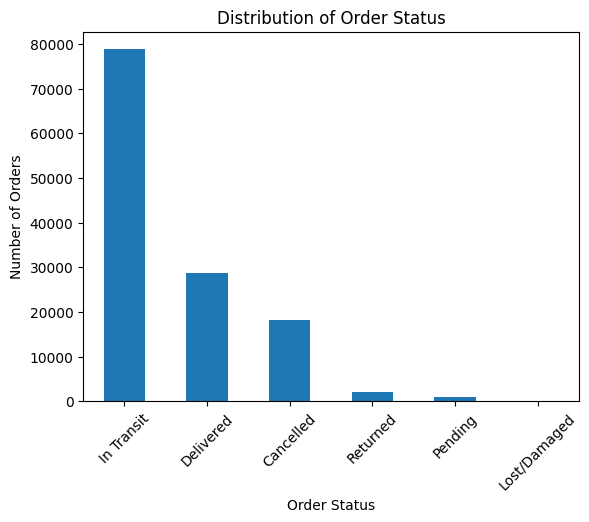

In [70]:
order_status.plot(kind="bar")

plt.title("Distribution of Order Status")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.show()

In [71]:
status_percentage = (
    df["order_status_group"]
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)

status_percentage

order_status_group
In Transit      61.11
Delivered       22.31
Cancelled       14.21
Returned         1.64
Pending          0.73
Lost/Damaged     0.00
Name: proportion, dtype: float64

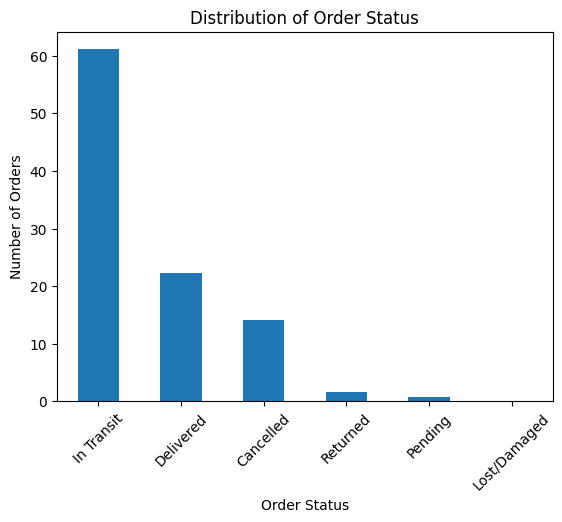

In [72]:
status_percentage.plot(kind="bar")

plt.title("Distribution of Order Status")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.show()

In [ ]:
# user="postgres"
# host="localhost"
# port="5432"
# password="SN0225"
# db="Amazon_sales"


# engine=create_engine(f"postgresql+psycopg2://{user}:{password}@{host}:{port}/{db}")

In [ ]:
# df.to_sql('sales',engine,if_exists="replace",index=False)